In [1]:
import cv2

In [2]:
!pip install matplotlib
!pip install --upgrade textract
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


Defaulting to user installation because normal site-packages is not writeable


DEPRECATION: textract 1.6.5 has a non-standard dependency specifier extract-msg<=0.29.*. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of textract or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [3]:
import matplotlib.pyplot as plt

In [4]:
config_file = 'ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
frozen_model = 'frozen_inference_graph.pb'

In [5]:
model = cv2.dnn_DetectionModel(frozen_model,config_file )

In [6]:
classLabels=[]
file_name = 'labels.txt'
with open (file_name,'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')

In [7]:
print(classLabels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [8]:
print(len(classLabels))

80


In [9]:
model.setInputSize(320,320)
model.setInputScale (1.0/127.5) 
model.setInputMean ((127.5,127.5,127.5)) 
model.setInputSwapRB (True)

< cv2.dnn.Model 0000016CD611DB30>

read an image

In [10]:
img = cv2.imread('handsome-man-standing-by-car-park.jpg')

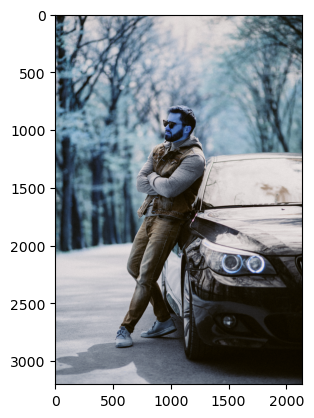

In [11]:
plt.imshow(img)

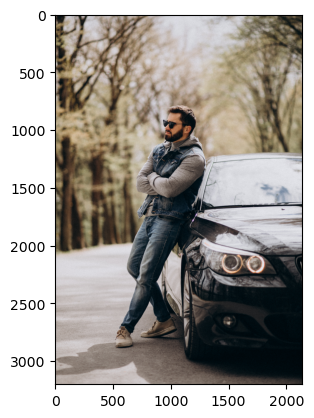

In [12]:
plt.imshow(cv2.cvtColor(img , cv2.COLOR_BGR2RGB))

In [13]:
ClassIndex, confidece, bbox, = model.detect(img, confThreshold=0.5)

In [14]:
print(ClassIndex)

[1 3]


In [15]:
font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
for ClassIndex, conf, boxes in zip(ClassIndex.flatten(), confidece.flatten(), bbox):
    cv2.rectangle(img,boxes,(255,0,0),2)
    cv2.putText(img,classLabels[ClassIndex-1],(boxes[0]+10,boxes[1]+40), font, fontScale=font_scale, color=(0,255,0), thickness=3)

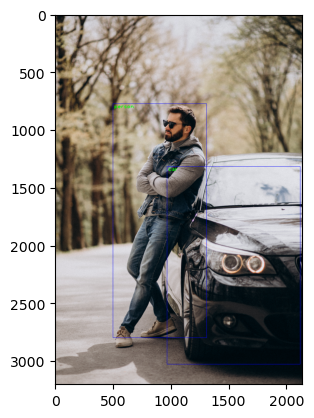

In [16]:
plt.imshow(cv2.cvtColor(img , cv2.COLOR_BGR2RGB))

In [ ]:
from ultralytics import YOLO
import cv2

# Load YOLOv5 model
model = YOLO('yolov5l.pt')

# Open webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Object detection
    results = model(frame)

    # Draw results
    annotated_frame = results[0].plot()

    # Show frame
    cv2.imshow('YOLOv5 Detection', annotated_frame)

    # Exit on Esc key
    if cv2.waitKey(1) == 27:  # Esc key
        break

cap.release()
cv2.destroyAllWindows()


ERROR Error reading from C:\Users\asus\AppData\Roaming\Ultralytics\settings.json: "No Ultralytics setting 'openvino_msg'. \nView Ultralytics Settings with 'yolo settings' or at 'C:\\Users\\asus\\AppData\\Roaming\\Ultralytics\\settings.json'\nUpdate Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings."
Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\asus\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP  Replace 'model=yolov5l.pt' with new 'model=yolov5lu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


0: 480x

In [ ]:
import cv2

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)  # Use DirectShow on Windows
if not cap.isOpened():
    raise IOError("Cannot open camera")

# Try to set resolution
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

# Check what actually got set
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
print(f"Camera resolution: {width} x {height}")
